In [67]:
%pip install  -e . 

Obtaining file:///Users/rolandmitric/WORK/GITHUB/master_programming_2026/live_notebooks
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for theochem_live (pyproject.toml) ... done
  Created wheel for theochem_live: filename=theochem_live-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=9adbb42ff33abcd16ca210660d57b408154845f0926ae8cb7ee1f3b0e310dc6b
  Stored in directory: /private/var/folders/jx/0m_kyw357_b256pffxmlcw2w0000gn/T/pip-ephem-wheel-cache-2p2ekryj/wheels/59/e8/ff/5287d38cd8dacfc9a1afddc99144d20a879c5c13951b373f14
Successfully built theochem_live
  Attempting uninstall: theochem_live
    Found existing installation: theochem_live 0.1.0
    Uninstalling theochem_live-0.1.0:
      Successfully uninstalled theochem_live-0.1.0

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To u

In [68]:
from src_live import Molecule, BasisSet, MolecularIntegrals, ELEMENT_SYMBOL, Shell, S, T, V, ERI

In [69]:
benzene_xyz = """12
Benzene molecule
C 0.000000 1.402720 0.000000
C 1.214790 0.701360 0.000000
C 1.214790 -0.701360 0.000000
C 0.000000 -1.402720 0.000000
C -1.214790 -0.701360 0.000000
C -1.214790 0.701360 0.000000
H 0.000000 2.490290 0.000000
H 2.156660 1.245150 0.000000
H 2.156660 -1.245150 0.000000
H 0.000000 -2.490290 0.000000
H -2.156660 -1.245150 0.000000
H -2.156660 1.245150 0.000000
"""

In [70]:
benzene = Molecule.from_string(benzene_xyz)
sto3g = BasisSet("sto-3g")
sto3g.download_from_bse(["C", "H"])
print(sto3g)

Dump data to sto-3g.json
Basis set: sto-3g
Element: H
l = 0, exponents = [3.42525091 0.62391373 0.1688554 ], coefficients = [0.15432897 0.53532814 0.44463454]
Element: C
l = 0, exponents = [71.61683735 13.04509632  3.53051216], coefficients = [0.15432897 0.53532814 0.44463454]
l = 0, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [-0.09996723  0.39951283  0.70011547]
l = 1, exponents = [2.94124936 0.6834831  0.22228992], coefficients = [0.15591627 0.60768372 0.39195739]



In [71]:
molints = MolecularIntegrals(benzene, sto3g)
S_my = molints.overlap_matrix()
T_my = molints.kinetic_matrix()
V_my = molints.nuclear_attraction_matrix()
ERI_my = molints.electron_repulsion_tensor(symmetrize = True)


Text(0.5, 1.0, 'log$_{10}$ |ERI|')

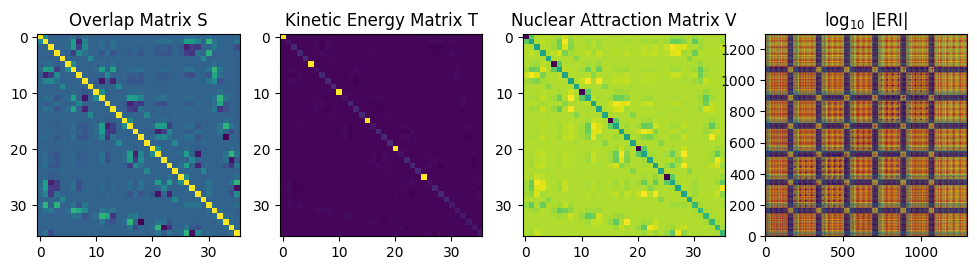

In [72]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 4, figsize = (12, 6))  

axes[0].imshow(S_my, cmap = "viridis")
axes[1].imshow(T_my, cmap = "viridis")
axes[0].set_title("Overlap Matrix S")
axes[1].set_title("Kinetic Energy Matrix T")
axes[2].imshow(V_my, cmap = "viridis")
axes[2].set_title("Nuclear Attraction Matrix V")
n = ERI_my.shape[0]
ERI2 = ERI_my.reshape(n * n, n * n)

im = axes[3].imshow(
    np.log10(np.abs(ERI2) + 1e-16),
    cmap="jet",
    origin="lower",
)
axes[3].set_title(r"log$_{10}$ |ERI|")


In [73]:
import pyscf
from pyscf import gto

mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)
S_pyscf = mol_pyscf.intor("int1e_ovlp")
T_pyscf = mol_pyscf.intor("int1e_kin")
V_pyscf = mol_pyscf.intor("int1e_nuc")
ERI_pyscf = mol_pyscf.intor("int2e").reshape(mol_pyscf.nao, mol_pyscf.nao, mol_pyscf.nao, mol_pyscf.nao)

Text(0.5, 1.0, 'log$_{10}$ |ERI|')

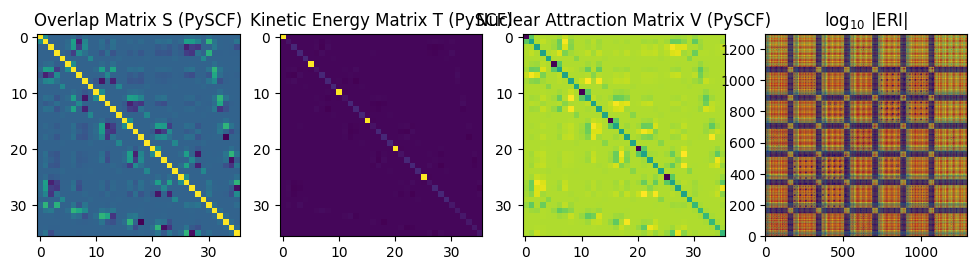

In [74]:
fig, axes = plt.subplots(1, 4, figsize = (12, 6))   

axes[0].imshow(S_pyscf, cmap = "viridis")
axes[1].imshow(T_pyscf, cmap = "viridis")
axes[0].set_title("Overlap Matrix S (PySCF)")
axes[1].set_title("Kinetic Energy Matrix T (PySCF)")
axes[2].imshow(V_pyscf, cmap = "viridis")
axes[2].set_title("Nuclear Attraction Matrix V (PySCF)")
n = ERI_pyscf.shape[0]
ERI2 = ERI_pyscf.reshape(n * n, n * n)

im = axes[3].imshow(
    np.log10(np.abs(ERI2) + 1e-16),
    cmap="jet",
    origin="lower",
)
axes[3].set_title(r"log$_{10}$ |ERI|")

In [75]:
from pyscf import gto

molints = MolecularIntegrals(benzene, sto3g)
mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)


%timeit molints.overlap_matrix()
%timeit mol_pyscf.intor("int1e_ovlp")

%timeit molints.kinetic_matrix()
%timeit mol_pyscf.intor("int1e_kin")

%timeit molints.nuclear_attraction_matrix()
%timeit mol_pyscf.intor("int1e_nuc")

%timeit molints.electron_repulsion_tensor()
%timeit mol_pyscf.intor("int2e")


79 μs ± 1.53 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
102 μs ± 2.16 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
98.5 μs ± 1.87 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
229 μs ± 4.15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.16 ms ± 65.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
902 μs ± 1.69 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
6.68 s ± 209 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
679 ms ± 10.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Hartree-Fock implementation

In [76]:
from __future__ import annotations
from dataclasses import dataclass
import numpy as np

@dataclass
class RHFResult:
    converged: bool
    iterations: int
    energy: float
    coeff: np.ndarray
    occ: np.ndarray
    mo_energies: np.ndarray
    density: np.ndarray


class RHF:
    def __init__(self, molecule: Molecule | None = None,
                 molints: MolecularIntegrals | None = None, 
                 max_cycle: int = 100, 
                 conv_tol: float = 1e-8) -> None:
        self.molecule = molecule
        self.molints = molints  
        self.max_cycle = max_cycle
        self.conv_tol = conv_tol
        self._initialized = False

        self.nel = self.molecule.n_electrons
        self.nocc = self.nel // 2

    def initialize(self, molecule: Molecule | None = None) -> None:

        self.S = self.molints.overlap_matrix()
        self.T = self.molints.kinetic_matrix()
        self.V = self.molints.nuclear_attraction_matrix()
        self.twoel = self.molints.electron_repulsion_tensor()

        eigval, eigvec = np.linalg.eigh(self.S)
        if np.any(eigval <= 1e-12):
            raise ValueError("Overlap matrix is singular or near-singular.")
        self.X = eigvec @ np.diag(eigval ** -0.5)

        self.hcore = self.T + self.V
        hcore_ortho = self.X.T @ self.hcore @ self.X
        _, c_ortho = np.linalg.eigh(hcore_ortho)
        c_occ = self.X @ c_ortho[:, : self.nocc]
        self.P = c_occ @ c_occ.T

    def get_fock(self, P: np.ndarray) -> np.ndarray:
        g = np.einsum(
            "kl,ijkl->ij",
            P,
            2.0 * self.twoel - self.twoel.transpose(0, 2, 1, 3),
            optimize=True,
        )
        return self.hcore + g

    def run_hf(
        self,
        max_iter: int | None = None,
        threshold: float | None = None,
        verbose: bool = True,
    ) -> RHFResult:
        self.initialize()

        n_iter = self.max_cycle if max_iter is None else max_iter
        conv_tol = self.conv_tol if threshold is None else threshold
        energy_last = 0.0
        energy = 0.0
        converged = False
        iteration = 0
        mo_energies = np.array([], dtype=float)
        coeff = np.array([], dtype=float)

        for iteration in range(1, n_iter + 1):
            fock = self.get_fock(self.P)
            fock_ortho = self.X.T @ fock @ self.X
            mo_energies, c_ortho = np.linalg.eigh(fock_ortho)
            coeff = self.X @ c_ortho

            c_occ = coeff[:, : self.nocc]
            p_new = c_occ @ c_occ.T
            energy = float(np.trace((self.hcore + fock) @ p_new))

            if verbose:
                print(f"Iteration {iteration}, Energy = {energy:.12f} Hartree")

            self.P = p_new
            if abs(energy - energy_last) < conv_tol:
                converged = True
                break
            energy_last = energy

        occ = np.zeros_like(mo_energies)
        occ[: self.nocc] = 2.0

        return RHFResult(
            converged=converged,
            iterations=iteration,
            energy=energy,
            coeff=coeff,
            occ=occ,
            mo_energies=mo_energies,
            density=self.P.copy(),
        )

    def run(self, molecule: Molecule | None = None, verbose: bool = True) -> RHFResult:
        if molecule is not None:
            self.initialize(molecule)
        return self.run_hf(max_iter=self.max_cycle, threshold=self.conv_tol, verbose=verbose)

In [77]:
hf = RHF(benzene, molints)
result = hf.run(verbose=True)
print(f"Final RHF Energy: {result.energy:.12f} Hartree")

Iteration 1, Energy = -395.398330286447 Hartree
Iteration 2, Energy = -441.531432416975 Hartree
Iteration 3, Energy = -428.830019860569 Hartree
Iteration 4, Energy = -430.399024980967 Hartree
Iteration 5, Energy = -430.302844654446 Hartree
Iteration 6, Energy = -430.309472100578 Hartree
Iteration 7, Energy = -430.309316185810 Hartree
Iteration 8, Energy = -430.309371032898 Hartree
Iteration 9, Energy = -430.309377319364 Hartree
Iteration 10, Energy = -430.309378823779 Hartree
Iteration 11, Energy = -430.309379097109 Hartree
Iteration 12, Energy = -430.309379148298 Hartree
Iteration 13, Energy = -430.309379157169 Hartree
Final RHF Energy: -430.309379157169 Hartree


In [78]:
mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)
mf_pyscf = pyscf.scf.RHF(mol_pyscf)
energy_pyscf = mf_pyscf.kernel()
print(f"Final RHF Energy (PySCF): {energy_pyscf:.12f} Hartree")

converged SCF energy = -227.88943025852
Final RHF Energy (PySCF): -227.889430258520 Hartree


## AO2MO transformation

After the SCF procedure, we have the converged molecular orbitals (MOs) and their corresponding energies. In order to go beyond the Hartree-Fock approximation e. g. by using configuration interaction (CI) or coupled cluster (CC) methods, we need to transform the one- and two-electron integrals from the atomic orbital (AO) basis to the molecular orbital (MO) basis.

Mathematically, this is just a change of basis, and it can be expressed as follows. For the one-electron integrals, we have:

$$
h_{pq} = \sum_{\mu\nu} C_{\mu p} C_{\nu q} h_{\mu\nu}
$$

where $h_{\mu\nu}$ are the one-electron integrals in the AO basis, $C_{\mu p}$ are the MO coefficients, and $h_{pq}$ are the one-electron integrals in the MO basis.  

For the two-electron integrals in the chemist's notation, we have:

$$
(pq|rs) = \sum_{\mu\nu\lambda\sigma} C_{\mu p} C_{\nu q} C_{\lambda r} C_{\sigma s} (\mu\nu|\lambda\sigma)
$$  

In Python we can implement this transformation using NumPy's `einsum` function, which allows for efficient tensor contractions. Below is an example of how to perform the AO to MO transformation for both one-electron and two-electron integrals.


In [79]:
def ao_to_mo_1e(h_ao, C):
    return np.einsum('mp,mn,nq->pq', C, h_ao, C)

def ao_to_mo_2e(g_ao, C):
    return np.einsum('mnlk,mp,nq,lr,ks->pqrs', g_ao, C, C, C, C, optimize=True)

In [80]:
# AO2MO transformation for benzene molecule using the coefficients from our RHF calculation
C = result.coeff
h_ao = hf.hcore
g_ao = hf.twoel

def ao_to_mo_1e(h_ao, C):
    return np.einsum('mp,mn,nq->pq', C, h_ao, C)

def ao_to_mo_2e(g_ao, C):
    return np.einsum('mnlk,mp,nq,lr,ks->pqrs', g_ao, C, C, C, C, optimize=True)    

In [81]:
h_mo = ao_to_mo_1e(h_ao, C)
g_mo = ao_to_mo_2e(g_ao, C)

In [82]:
from pyscf import ao2mo

h_mo_pyscf = C.T @ mf_pyscf.get_hcore() @ C
g_mo_pyscf = ao2mo.restore(1, ao2mo.kernel(mol_pyscf, C), C.shape[1])

In [83]:
print("max |h_mo - h_mo_pyscf| =", np.max(np.abs(h_mo - h_mo_pyscf)))
print("max |g_mo - g_mo_pyscf| =", np.max(np.abs(g_mo - g_mo_pyscf)))
print(np.allclose(h_mo, h_mo_pyscf, atol=1e-5))
print(np.allclose(g_mo, g_mo_pyscf, atol=1e-6))

max |h_mo - h_mo_pyscf| = 2.4911604477040328e-06
max |g_mo - g_mo_pyscf| = 1.6590938173299818e-07
True
True


In [84]:
from dataclasses import dataclass
import numpy as np


@dataclass
class CISResult:
    excitation_energies: np.ndarray
    total_energies: np.ndarray
    coefficients: np.ndarray
    basis: list[tuple[int, int]]

class ConfigurationInteraction:
    def __init__(self, h_mo, g_mo):
        self.h_mo = h_mo
        self.g_mo = g_mo
        self.norb = h_mo.shape[0]      # number of spatial orbitals
        self.num_modes = 2 * self.norb # number of spin orbitals

    def vacuum(self):
        return 0

    def occupation(self, state, site):
        return (state >> site) & 1

    def count_particles(self, state):
        return state.bit_count()

    def parity_before(self, state, site):
        mask = (1 << site) - 1
        num_before = (state & mask).bit_count()
        return -1 if num_before % 2 else 1

    def create(self, state, site):
        if self.occupation(state, site) == 1:
            return 0, None
        coeff = self.parity_before(state, site)
        new_state = state | (1 << site)
        return coeff, new_state

    def annihilate(self, state, site):
        if self.occupation(state, site) == 0:
            return 0, None
        coeff = self.parity_before(state, site)
        new_state = state & ~(1 << site)
        return coeff, new_state

    def number(self, state, site):
        return self.occupation(state, site), state

    def state_to_occupations(self, state):
        return [(state >> i) & 1 for i in range(self.num_modes)]

    def occupations_to_state(self, occupations):
        state = 0
        for i, n_i in enumerate(occupations):
            if n_i:
                state |= (1 << i)
        return state

    def pretty(self, state):
        occs = self.state_to_occupations(state)
        return "|" + ",".join(str(n) for n in occs) + ">"

    def rhf_reference(self, nocc):
        # spin-orbital ordering: 0a,0b,1a,1b,2a,2b,...
        occs = [0] * self.num_modes
        for i in range(nocc):
            occs[2 * i] = 1
            occs[2 * i + 1] = 1
        return self.occupations_to_state(occs)

    def cis_basis(self, nocc):
        # basis element (i, a) means singlet excitation i -> a
        return [(i, a) for i in range(nocc) for a in range(nocc, self.norb)]

    def cis_hamiltonian(self, mo_energies, occ):
        nocc = int(np.count_nonzero(np.asarray(occ) > 0))
        basis = self.cis_basis(nocc)
        dim = len(basis)
        H = np.zeros((dim, dim))

        for I, (i, a) in enumerate(basis):
            for J, (j, b) in enumerate(basis):
                if i == j and a == b:
                    H[I, J] += mo_energies[a] - mo_energies[i]

                # singlet CIS matrix element:
                # A_ia,jb = delta_ij delta_ab (eps_a - eps_i) + 2 (ai|jb) - (ab|ji)
                H[I, J] += 2.0 * self.g_mo[a, i, j, b] - self.g_mo[a, b, j, i]

        return H, basis

    def cis(self, rhf_result):
        H, basis = self.cis_hamiltonian(rhf_result.mo_energies, rhf_result.occ)
        excitation_energies, coefficients = np.linalg.eigh(H)

        return CISResult(
            excitation_energies=excitation_energies,
            total_energies=rhf_result.energy + excitation_energies,
            coefficients=coefficients,
            basis=basis,
        )

In [85]:
ci = ConfigurationInteraction(h_mo, g_mo)
cis = ci.cis(result)

print(cis.excitation_energies[:5])
print(cis.total_energies[:5])
print(cis.basis[:5])   # [(i,a), ...]

[0.27882351 0.29951788 0.37745303 0.38363191 0.38363193]
[-430.03055565 -430.00986128 -429.93192613 -429.92574725 -429.92574723]
[(0, 21), (0, 22), (0, 23), (0, 24), (0, 25)]


In [86]:
from pyscf import scf, tdscf

C = result.coeff
h_mo_test = np.einsum('mp,mn,nq->pq', C, hf.hcore, C)
g_mo_test = np.einsum('mnlk,mp,nq,lr,ks->pqrs', hf.twoel, C, C, C, C, optimize=True)

ci = ConfigurationInteraction(h_mo_test, g_mo_test)
H_my, _ = ci.cis_hamiltonian(result.mo_energies, result.occ)
e_my = ci.cis(result).excitation_energies

mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis="sto-3g",
    unit="Angstrom",
)
mf_pyscf = scf.RHF(mol_pyscf)
mf_pyscf.kernel(verbose=0)

A_ref, _ = tdscf.rhf.get_ab(
    mf_pyscf,
    mo_energy=result.mo_energies,
    mo_coeff=result.coeff,
    mo_occ=result.occ,
)
A_ref = A_ref.reshape(A_ref.shape[0] * A_ref.shape[1], -1)
e_ref = np.linalg.eigvalsh(A_ref)

print("max |H_my - A_ref| =", np.max(np.abs(H_my - A_ref)))
print("max |e_my - e_ref| =", np.max(np.abs(e_my - e_ref)))
print(np.allclose(H_my, A_ref, atol=1e-6))
print(np.allclose(e_my, e_ref, atol=1e-6))

converged SCF energy = -227.88943025852
max |H_my - A_ref| = 7.336162077820063e-08
max |e_my - e_ref| = 1.320623557177214e-07
True
True
